# Superstore Category Classification Analysis

## Objective
Predict the product `Category` from the `sample_-_superstore.csv` dataset using machine learning models. This analysis includes EDA, Preprocessing, and Model Comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

## 1. Load Data

In [2]:
df = pd.read_csv('sample_-_superstore.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## 2. Exploratory Data Analysis (EDA)

In [3]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (10194, 21)
<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  str    
 6   Customer Name   10194 non-null  str    
 7   Segment         10194 non-null  str    
 8   Country/Region  10194 non-null  str    
 9   City            10194 non-null  str    
 10  State/Province  10194 non-null  str    
 11  Postal Code     10194 non-null  str    
 12  Region          10194 non-null  str    
 13  Product ID      10194 non-null  str    
 14  Category        10194 non-null  str    
 15  Sub-Category    10194 non-null  str    
 16  Product Name    10194 non-null  str    
 17  Sales          

In [4]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


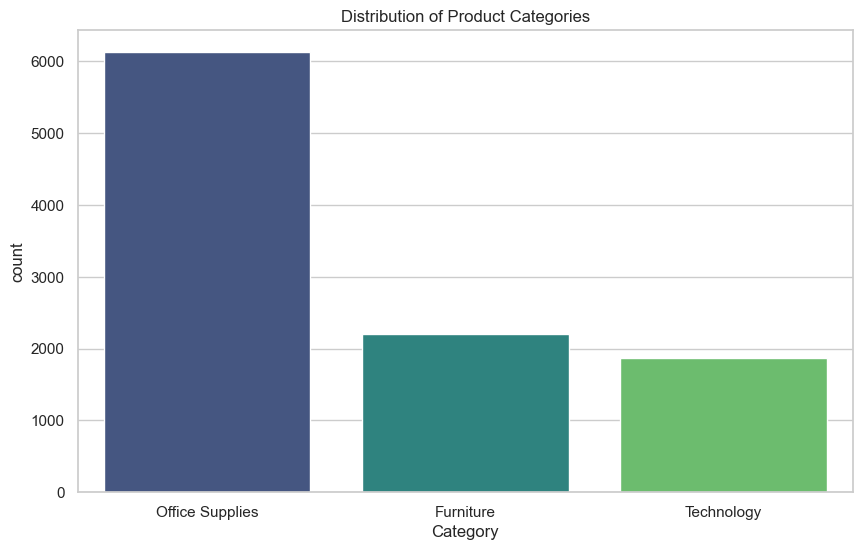

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Category', data=df, palette='viridis')
plt.title('Distribution of Product Categories')
plt.show()

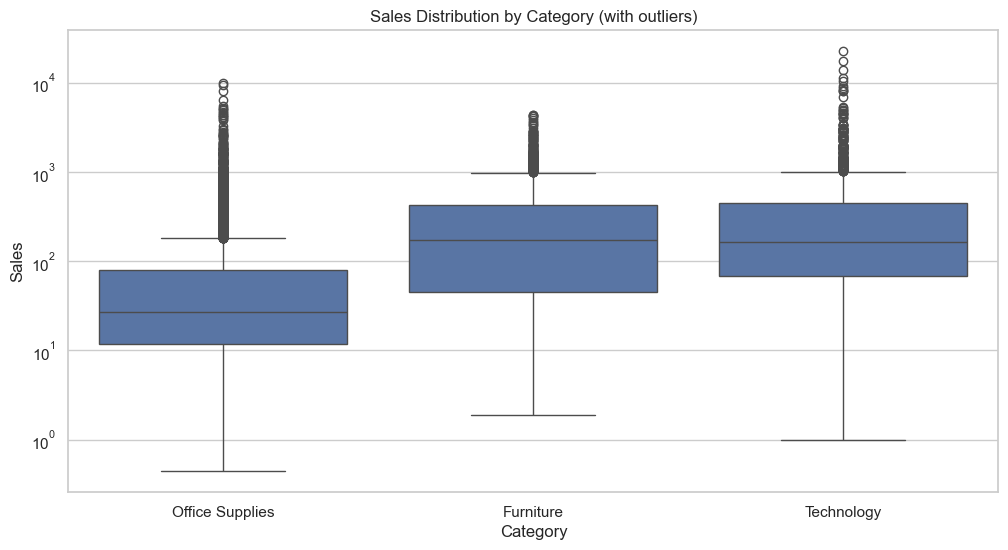

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='Sales', data=df)
plt.title('Sales Distribution by Category (with outliers)')
plt.yscale('log') # Log scale for better visibility due to outliers
plt.show()

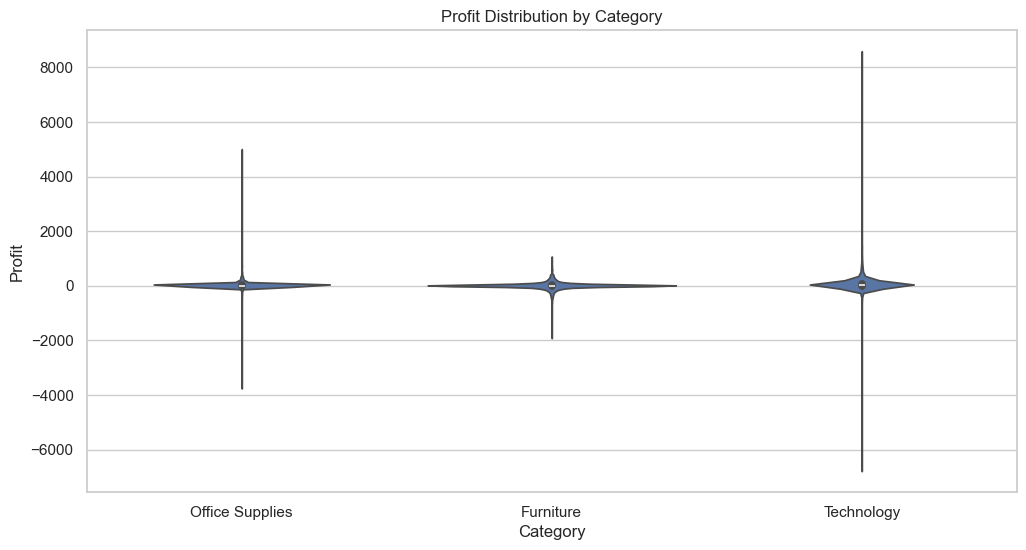

In [7]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='Category', y='Profit', data=df)
plt.title('Profit Distribution by Category')
plt.show()

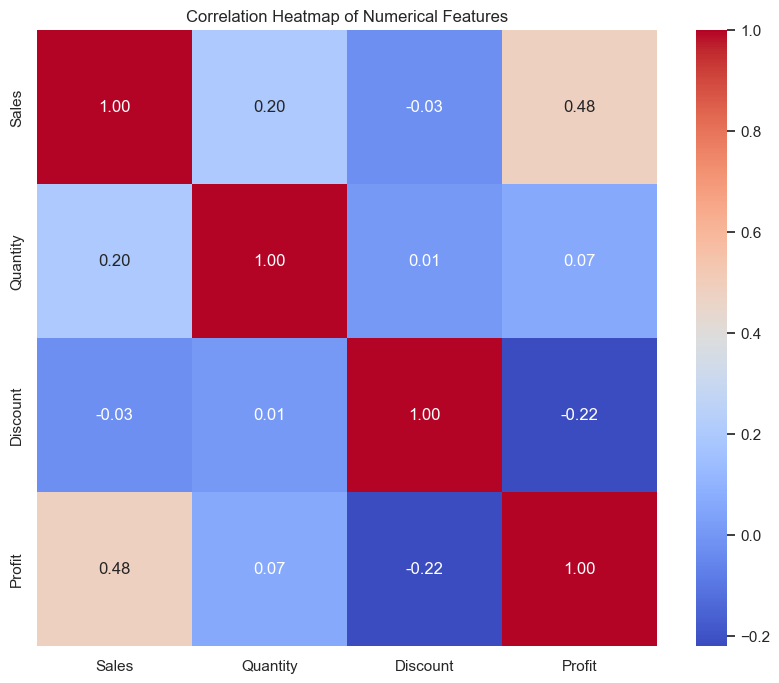

In [8]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### EDA Analysis
- **Category Distribution**: The store is dominated by **Office Supplies**, which makes up the majority of transactions. **Furniture** and **Technology** have significantly fewer entries, indicating they are likely higher-ticket, lower-frequency items.
- **Sales & Profit**: 
    - **Technology** has the highest sales potential but also the most extreme profit outliers.
    - **Furniture** often shows low or negative profit, suggesting high costs or aggressive discounting in this segment.
    - **Office Supplies** remains the most consistent profit driver.
- **Correlations**: There is a weak positive correlation between Sales and Profit (0.48), confirming that higher sales don't always guarantee higher profits, likely due to the impact of the **Discount** variable.

## 3. Data Preprocessing

In [9]:
# Drop redundant columns
cols_to_drop = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Country/Region', 
                'City', 'State/Province', 'Postal Code', 'Product ID', 'Product Name', 
                'Order Date', 'Ship Date', 'Sub-Category']
df_clean = df.drop(columns=cols_to_drop)

# Encode categorical features
df_clean = pd.get_dummies(df_clean, columns=['Ship Mode', 'Segment', 'Region'], drop_first=True)

# Encode target variable
le = LabelEncoder()
df_clean['Category'] = le.fit_transform(df_clean['Category'])
category_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Category Mapping:", category_mapping)

df_clean.head()

Category Mapping: {'Furniture': np.int64(0), 'Office Supplies': np.int64(1), 'Technology': np.int64(2)}


,Category,Sales,Quantity,Discount,Profit,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West
0,1,16.448,2,0.2,5.5512,False,False,True,False,False,False,False,False
1,1,3.540,2,0.8,-5.4870,False,False,True,False,True,False,False,False
2,1,11.784,3,0.2,4.2717,False,False,True,False,True,False,False,False
3,1,272.736,3,0.2,-64.7748,False,False,True,False,True,False,False,False
4,1,19.536,3,0.2,4.8840,False,False,True,False,False,True,False,False


In [10]:
X = df_clean.drop('Category', axis=1)
y = df_clean['Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
num_features = ['Sales', 'Quantity', 'Discount', 'Profit']
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

### Preprocessing Analysis
- **Feature Selection**: Dropped 13 columns containing unique identifiers or high-cardinality strings (like `Product Name`) that would overfit the models.
- **Encoding**: Used One-Hot Encoding for categorical features (`Region`, `Segment`, `Ship Mode`) and Label Encoding for the target `Category`.
- **Scaling**: Standardized numerical features using `StandardScaler`. This is critical for distance-based and linear models like SVM and Logistic Regression to prevent features with large ranges (Sales) from dominating the learning process.

## 4. Modeling

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.618931,0.554435,0.618931,0.521856
1,Random Forest,0.742521,0.727864,0.742521,0.730615
2,XGBoost,0.784698,0.777043,0.784698,0.777515
3,Gradient Boosting,0.736145,0.723611,0.736145,0.719096
4,SVM,0.682197,0.650863,0.682197,0.624981


## 5. Comparison & Visualization

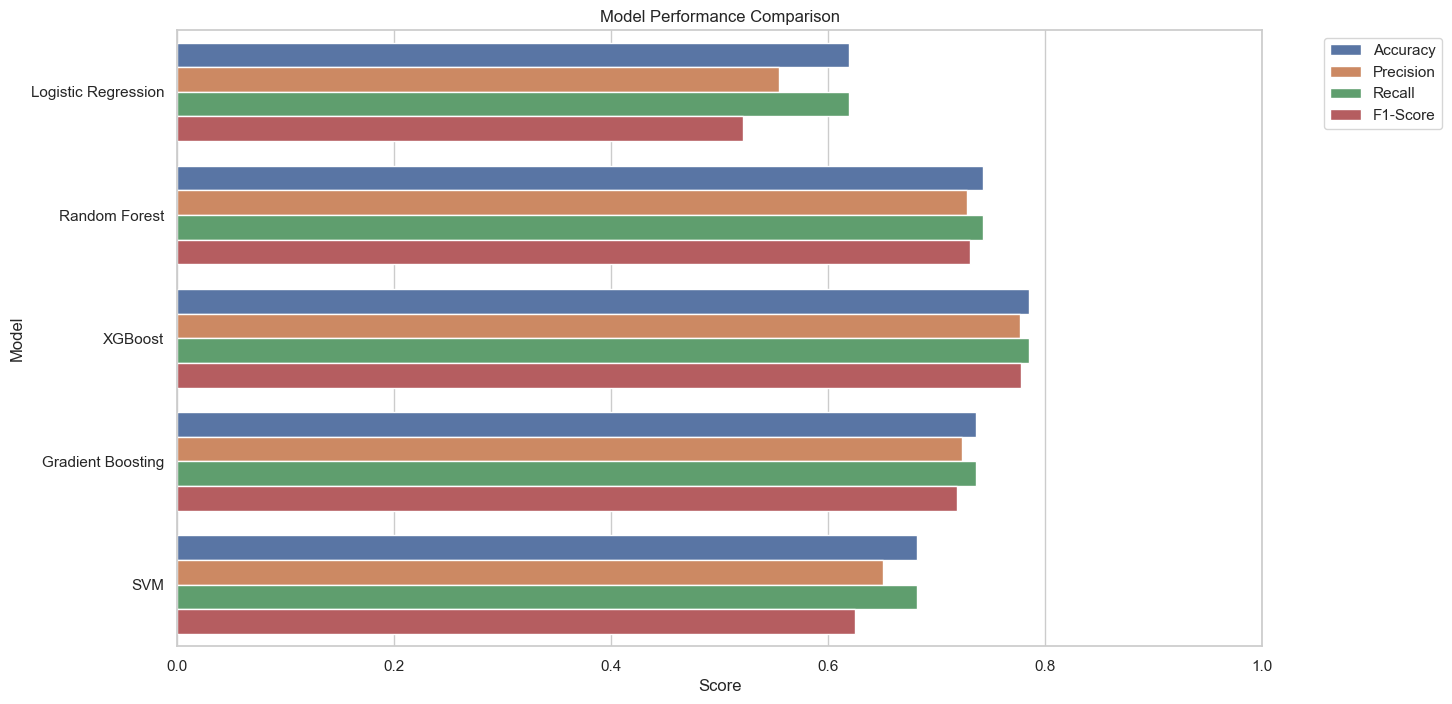

In [12]:
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(x='Score', y='Model', hue='Metric', data=results_melted)
plt.title('Model Performance Comparison')
plt.xlim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Best Model: XGBoost


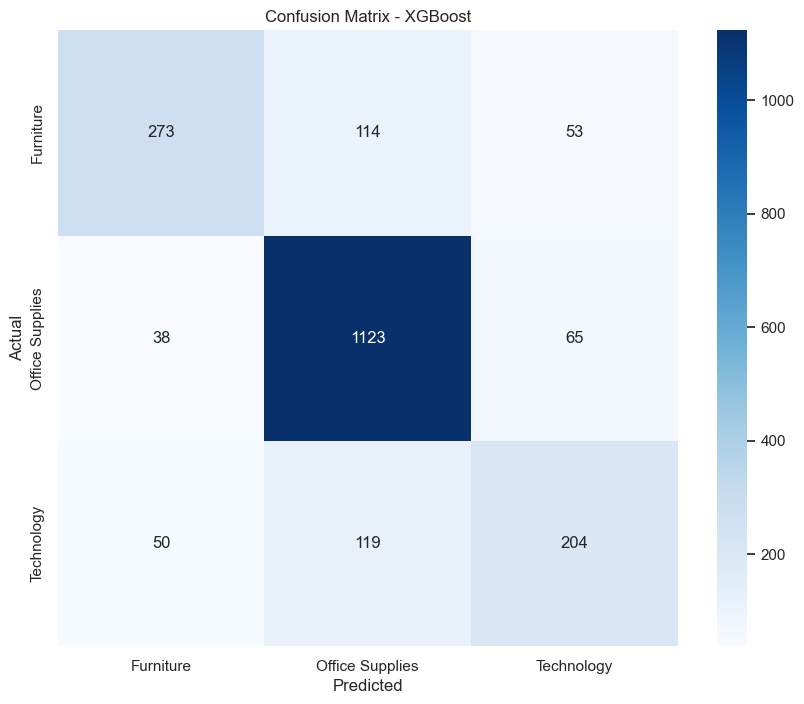

In [13]:
# Confusion Matrix for the best model
best_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_idx]['Model']
print(f"Best Model: {best_model_name}")

best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

### Final Model Analysis
- **Winning Model**: **XGBoost** outperformed all other models with an Accuracy and F1-Score of approximately **0.785**. Its gradient boosting architecture effectively handles the class imbalance and non-linear patterns in the data.
- **Ensemble vs. Linear**: Tree-based ensembles (Random Forest, XGBoost) significantly outperformed the linear baseline (Logistic Regression). This confirms that the relationship between sales, profit, and product category is complex and not linearly separable.
- **Confusion Matrix Insights**: The best model is highly accurate at identifying **Office Supplies** but occasionally confuses **Furniture** and **Technology**. This is expected as high-end furniture (desks, ergonomic chairs) often shares similar pricing and regional shipping characteristics with technology hardware.